In [20]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [27]:
# ==============================
# PARÂMETROS GERAIS
# ==============================

L = 100
n_lagartos = L**2
estrategias = ['O', 'Y', 'B']

a = 2
b = 1/a

matriz_payoff = np.array([[1, b, a],
                          [a, 1, b],
                          [b, a, 1]])

index_map = {'O': 0, 'Y': 1, 'B': 2}

n_geracoes = 50
n_pop = 1

R_max = 8
mu_raio = 0.0001
c_O = 0.5
c_B = 0.3
c_Y = 0.4
prob = 0.5

output_dir = output_dir = f"C:\\Unicamp\\mestrado\\simulacoes\\RPS-python\\RPS-POO\\outputs\\raio_evolutivo\\custo_diferente_todas\\cO{c_O}_cB{c_B}_cY{c_Y}\\"
os.makedirs(output_dir, exist_ok=True)

In [28]:
# ==============================
# CLASSE LAGARTO
# ==============================

class Lagarto:
    def __init__(self, i, j, estrategia, raio, fitness,
                 coord_vizinhos, estrategia_vizinhos, coord_vizinhanca_extendida,
                 estrategia_vizinhanca_extendida, n_vizinhos):
        self.i = i
        self.j = j
        self.estrategia = estrategia
        self.raio = raio
        self.fitness = 0
        self.coord_vizinhos = []
        self.estrategia_vizinhos = []
        self.coord_vizinhanca_extendida = []
        self.estrategia_vizinhanca_extendida = []
        self.n_vizinhos = 0

    def calcular_coord_vizinhos(self, L):
        lista_vizinhos = []
        r = self.raio

        # vizinhança de Von Neumann
        for dx in range(-r, r+1):
            for dy in range(-r, r+1):
                if abs(dx) + abs(dy) <= r and not (dx == 0 and dy == 0):
                    ni = (self.i + dx) % L
                    nj = (self.j + dy) % L
                    lista_vizinhos.append((ni, nj))

        self.coord_vizinhos = lista_vizinhos

    def mutacao_raio(self):
        if np.random.rand() < mu_raio:
            self.raio += np.random.choice([-1, 1])
            self.raio = max(1, min(R_max, self.raio))


    def calcular_n_vizinhos(self):
      self.n_vizinhos = len(self.estrategia_vizinhos) + len(self.estrategia_vizinhanca_extendida)


# ==============================
# FUNÇÕES AUXILIARES
# ==============================

def criar_lagartos():
    lista = []
    for i in range(L):
        for j in range(L):
            estrategia = np.random.choice(estrategias)
            raio = np.random.randint(1, R_max+1)
            lista.append(Lagarto(i, j, estrategia, raio, 0, [], [], [], [], 0))
    
    return lista


def ajustar_vizinhos_reciprocos(lagartos): 
    mapa = {(l.i, l.j): l for l in lagartos}

    for l in lagartos:
        for (ni, nj) in l.coord_vizinhos: 
            vizinho = mapa[(ni, nj)]
            if (l.i, l.j) not in vizinho.coord_vizinhos:
                vizinho.estrategia_vizinhanca_extendida.append(str(l.estrategia))
                vizinho.coord_vizinhanca_extendida.append((l.i, l.j))
                vizinho.calcular_n_vizinhos()


def calcular_fitness(lagarto, matriz_posicao, c, s):
    fitness_total = 0

    todos_vizinhos = set(lagarto.coord_vizinhos + lagarto.coord_vizinhanca_extendida) 
    for ni, nj in todos_vizinhos:
        vizinho_estrat = matriz_posicao[ni, nj] 
        if vizinho_estrat is not None:
            fitness_total += matriz_payoff[index_map[lagarto.estrategia], 
                                           index_map[vizinho_estrat]] 
    
    # custo linear do raio
    lagarto.fitness = fitness_total - (s * c * lagarto.raio**2) # área, quadratico

def atualizar_lagartos(lista_lagartos):

    mapa = {(l.i, l.j): l for l in lista_lagartos}
    novas_info = {}

    for lagarto in lista_lagartos:

        melhor_estrategia = lagarto.estrategia
        melhor_raio = lagarto.raio
        maior_fitness = lagarto.fitness

        todos_vizinhos = set(lagarto.coord_vizinhos + lagarto.coord_vizinhanca_extendida) 
        for (ni, nj) in todos_vizinhos:
            vizinho = mapa[(ni, nj)]

            if vizinho.fitness > maior_fitness:
                maior_fitness = vizinho.fitness
                melhor_estrategia = vizinho.estrategia
                melhor_raio = vizinho.raio
            elif vizinho.fitness == maior_fitness:
                a = np.random.rand()
                if a < 0.5:
                    maior_fitness = vizinho.fitness 
                    melhor_estrategia = vizinho.estrategia
                    melhor_raio = vizinho.raio
                else:
                    pass

        novas_info[(lagarto.i, lagarto.j)] = (melhor_estrategia, melhor_raio)

    for lagarto in lista_lagartos:
        nova_estrategia, novo_raio = novas_info[(lagarto.i, lagarto.j)]
        lagarto.estrategia = nova_estrategia
        lagarto.raio = novo_raio
        lagarto.mutacao_raio()

    return lista_lagartos


def calcular_freq(matriz):
    return np.array([np.sum(matriz == s) / (L**2) for s in estrategias])


def media_raio(lista_lagartos):
    return np.mean([l.raio for l in lista_lagartos])

def media_raio_por_estrategia(lista_lagartos):
    medias = []
    for e in estrategias:
        raios = [l.raio for l in lista_lagartos if l.estrategia == e]
        medias.append(np.mean(raios) if len(raios) > 0 else np.nan)
    return medias

In [ ]:
# ==============================
# SIMULAÇÃO
# ==============================

def simulacao(seed=None):

    resultados = []

    for pop in range(n_pop):

        if seed is not None:
            np.random.seed(seed + pop)

        lista_lagartos = criar_lagartos()

        matriz_posicao = np.empty((L, L), dtype=object)
        for l in lista_lagartos:
            matriz_posicao[l.i, l.j] = l.estrategia

        freq = calcular_freq(matriz_posicao)
        r_mean = media_raio(lista_lagartos)
        r_por_estrat = media_raio_por_estrategia(lista_lagartos)
        resultados.append({
            "pop": pop,
            "t": -1,
            "freq_O": freq[0],
            "freq_Y": freq[1],
            "freq_B": freq[2],
            "r_mean": r_mean,
            "r_O": r_por_estrat[0],
            "r_Y": r_por_estrat[1],
            "r_B": r_por_estrat[2]
        })

        for t in range(n_geracoes):
            print(f"População {pop+1} - Geração {t+1}/{n_geracoes}")

            # calcular vizinhos
            for l in lista_lagartos:
                l.calcular_coord_vizinhos(L)
                l.coord_vizinhanca_extendida = []
                l.estrategia_vizinhanca_extendida = [] 
            
            ajustar_vizinhos_reciprocos(lista_lagartos)

            # calcular fitness
            for l in lista_lagartos:
                l.calcular_n_vizinhos()
                if l.estrategia == 'Y':
                    calcular_fitness(l, matriz_posicao, c_Y, 1)
                    #x = np.random.rand()
                    #if x < prob:
                        #s = 1
                    #else:
                        #s = 0
                elif l.estrategia == 'O':
                    #s = 1
                    calcular_fitness(l, matriz_posicao, c_O, 1)
                elif l.estrategia == 'B':
                    #s = 1
                    calcular_fitness(l, matriz_posicao, c_B, 1)

            # atualizar estratégias e raios
            lista_lagartos = atualizar_lagartos(lista_lagartos)

            # atualizar matriz
            for l in lista_lagartos:
                matriz_posicao[l.i, l.j] = l.estrategia

            # registrar métricas
            freq = calcular_freq(matriz_posicao)
            r_mean = media_raio(lista_lagartos)
            r_por_estrat = media_raio_por_estrategia(lista_lagartos)

            resultados.append({
                "pop": pop,
                "t": t,
                "freq_O": freq[0],
                "freq_Y": freq[1],
                "freq_B": freq[2],
                "r_mean": r_mean,
                "r_O": r_por_estrat[0],
                "r_Y": r_por_estrat[1],
                "r_B": r_por_estrat[2]
            })

    return pd.DataFrame(resultados)


# ==============================
# RODAR
# ==============================

df = simulacao(seed=3)
df.to_csv(os.path.join(output_dir, "resultados.csv"), index=False)

print("Simulação concluída.")

População 1 - Geração 1/50
População 1 - Geração 2/50
População 1 - Geração 3/50
População 1 - Geração 4/50
População 1 - Geração 5/50
População 1 - Geração 6/50
População 1 - Geração 7/50
População 1 - Geração 8/50
População 1 - Geração 9/50
População 1 - Geração 10/50
População 1 - Geração 11/50
População 1 - Geração 12/50
População 1 - Geração 13/50
População 1 - Geração 14/50
População 1 - Geração 15/50
População 1 - Geração 16/50
População 1 - Geração 17/50
População 1 - Geração 18/50
População 1 - Geração 19/50
População 1 - Geração 20/50
População 1 - Geração 21/50
População 1 - Geração 22/50
População 1 - Geração 23/50
População 1 - Geração 24/50
População 1 - Geração 25/50
População 1 - Geração 26/50
População 1 - Geração 27/50
População 1 - Geração 28/50
População 1 - Geração 29/50
População 1 - Geração 30/50
População 1 - Geração 31/50
População 1 - Geração 32/50
População 1 - Geração 33/50
População 1 - Geração 34/50


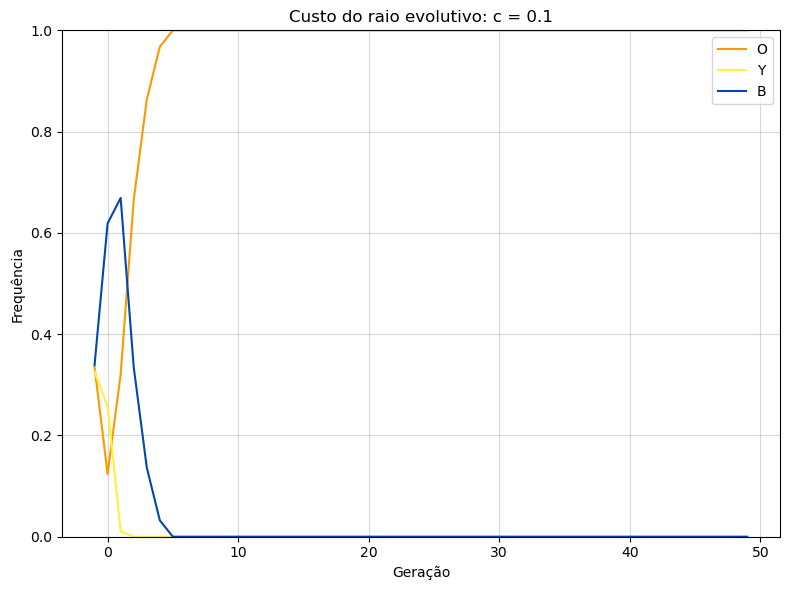

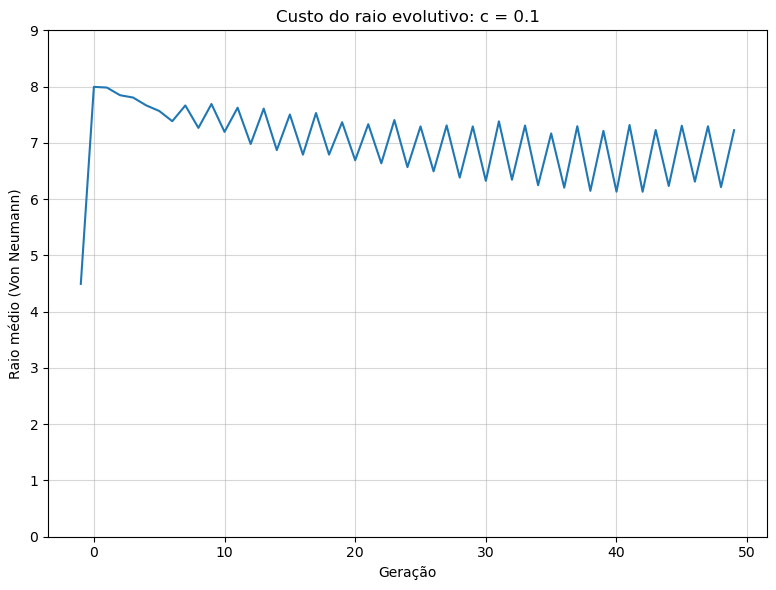

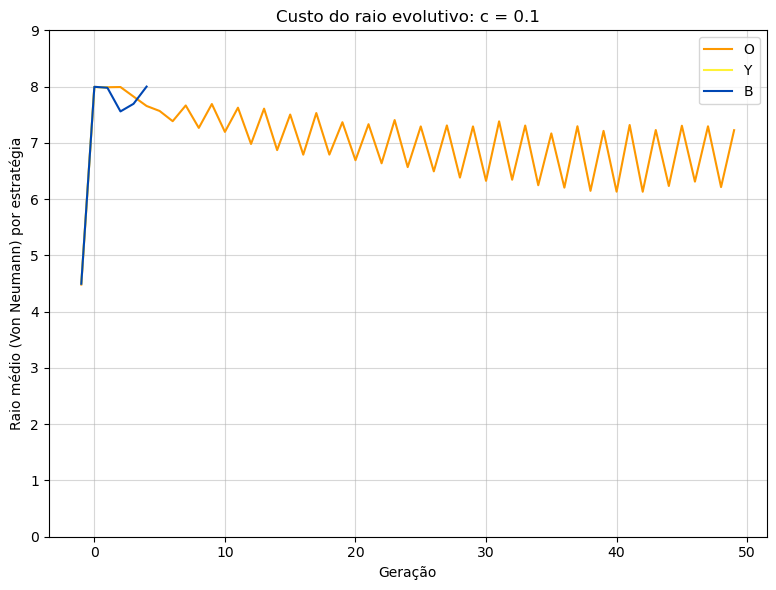

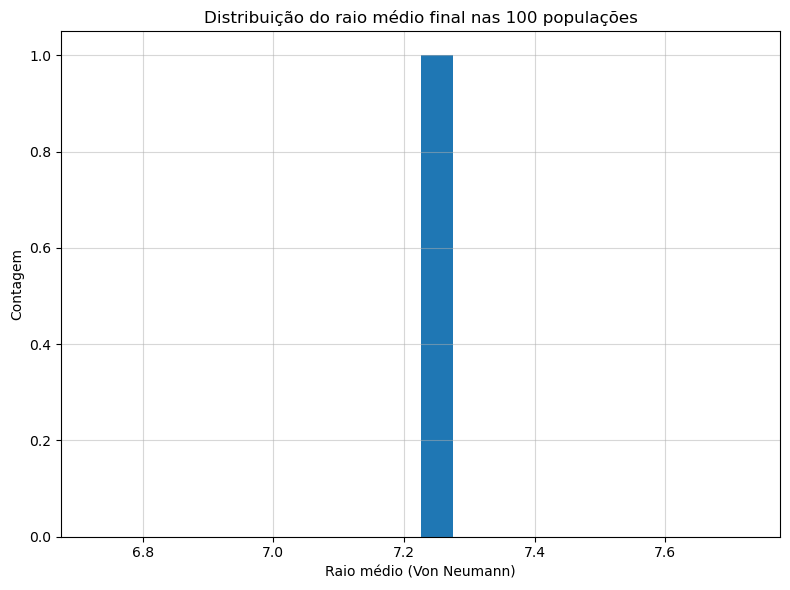

Plots gerados com sucesso.


In [ ]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

# calcular médias entre populações
df_mean = df.groupby("t").mean(numeric_only=True).reset_index()
df_sd = df.groupby("t").std(numeric_only=True).reset_index()

# ============================
# FREQUÊNCIAS DAS ESTRATÉGIAS
# ============================

plt.figure(figsize=(8,6))

plt.plot(df_mean["t"], df_mean["freq_O"], label="O", color=cores["O"])
plt.plot(df_mean["t"], df_mean["freq_Y"], label="Y", color=cores["Y"])
plt.plot(df_mean["t"], df_mean["freq_B"], label="B", color=cores["B"])
plt.fill_between(df_mean["t"], df_mean["freq_O"] - df_sd["freq_O"], df_mean["freq_O"] + df_sd["freq_O"], color=cores["O"], alpha=0.2)
plt.fill_between(df_mean["t"], df_mean["freq_Y"] - df_sd["freq_Y"], df_mean["freq_Y"] + df_sd["freq_Y"], color=cores["Y"], alpha=0.2)
plt.fill_between(df_mean["t"], df_mean["freq_B"] - df_sd["freq_B"], df_mean["freq_B"] + df_sd["freq_B"], color=cores["B"], alpha=0.2)

plt.xlabel("Geração")
plt.ylabel("Frequência")
plt.title("Custo do raio evolutivo: c = " + str(c))
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)
plt.grid(True, alpha=0.5)
plt.savefig(os.path.join(output_dir, "frequencias.png"), dpi=300)
plt.show()
plt.close()


# ============================
# RAIO MÉDIO TOTAL
# ============================

plt.figure(figsize=(8,6))

plt.plot(df_mean["t"], df_mean["r_mean"])
plt.fill_between(df_mean["t"], df_mean["r_mean"] - df_sd["r_mean"], df_mean["r_mean"] + df_sd["r_mean"], alpha=0.2)

plt.xlabel("Geração")
plt.ylabel("Raio médio (Von Neumann)")
plt.title("Custo do raio evolutivo: c = " + str(c))
plt.tight_layout()
plt.ylim(0, R_max + 1)
plt.grid(True, alpha=0.5)
plt.savefig(os.path.join(output_dir, "raio_medio_total.png"), dpi=300)
plt.show()
plt.close()


# ============================
# RAIO MÉDIO POR ESTRATÉGIA
# ============================

plt.figure(figsize=(8,6))

plt.plot(df_mean["t"], df_mean["r_O"], label="O", color=cores["O"])
plt.plot(df_mean["t"], df_mean["r_Y"], label="Y", color=cores["Y"])
plt.plot(df_mean["t"], df_mean["r_B"], label="B", color=cores["B"])
plt.fill_between(df_mean["t"], df_mean["r_O"] - df_sd["r_O"], df_mean["r_O"] + df_sd["r_O"], color=cores["O"], alpha=0.2)
plt.fill_between(df_mean["t"], df_mean["r_Y"] - df_sd["r_Y"], df_mean["r_Y"] + df_sd["r_Y"], color=cores["Y"], alpha=0.2)
plt.fill_between(df_mean["t"], df_mean["r_B"] - df_sd["r_B"], df_mean["r_B"] + df_sd["r_B"], color=cores["B"], alpha=0.2)


plt.xlabel("Geração")
plt.ylabel("Raio médio (Von Neumann) por estratégia")
plt.title("Custo do raio evolutivo: c = " + str(c))
plt.legend()
plt.tight_layout()
plt.ylim(0, R_max + 1)
plt.grid(True, alpha=0.5)
plt.savefig(os.path.join(output_dir, "raio_por_estrategia.png"), dpi=300)
plt.show()
plt.close()


# ============================
# DISTRIBUIÇÃO FINAL DO RAIO
# ============================

# pegar última geração
ultima_geracao = df["t"].max()
df_final = df[df["t"] == ultima_geracao]

plt.figure(figsize=(8,6))
plt.hist(df_final["r_mean"], bins=20)

plt.xlabel("Raio médio (Von Neumann)")
plt.ylabel("Contagem")
plt.title("Distribuição do raio médio final nas 100 populações")
plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.savefig(os.path.join(output_dir, "distribuicao_raio_final.png"), dpi=300)
plt.show()
plt.close()


print("Plots gerados com sucesso.")
